Feature engineering: https://www.analyticsvidhya.com/blog/2019/12/6-powerful-feature-engineering-techniques-time-series/

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)

Mounted at /content/gdrive


In [ ]:
import os
os.chdir("/content/gdrive/My Drive/TL_A/DeepKale/experiments_0.2/")

In [ ]:
%%capture
!pip install optuna torch plotly botorch

## Coding

In [ ]:
# Import packages
import os
import warnings
import torch
import datetime
import pickle as pkl
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px


import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from botorch.acquisition.monte_carlo import qExpectedImprovement

In [ ]:
from src.hyperparameter_optimization.botorch_optimization_function import gen_initial_data, get_fitted_model, optimize_acqf_and_get_observation
from src.preprocessing.data_preparation import DataPreparation
from src.preprocessing.feature_scaling import robust_scaling, min_max_scaling
from src.preprocessing.feature_engineering import feature_encoding, create_temporal_features, create_lag_features, expanding_mean_std_weighted_avg
from src.model.base_model.tcn_model import TCNModel
from src.utils.helper_functions import get_approach
from src.utils.evaluate import evaluate_model
from src.utils.train import train
from src.utils.test import test
from src.utils.postprocessing import process_data
from src.utils.metrics import performance_metrics
from src.utils.line_plotting import create_line_plot

In [ ]:
def save_losses(trial_result_file, filepath, iterations, hyperparameters, train_losses, val_losses):
    with open(filepath, 'a') as file:
        file.write(f'Iteration {iterations}, hyperparameters: {hyperparameters}\n')

        for epoch in range(len(train_losses)):
            file.write(f'Epoch {epoch}: train loss = {train_losses[epoch]}, val loss = {val_losses[epoch]}\n')


def objective(parameterization, iter_num, best_iteration, best_loss):

    num_hidden_layers = round(parameterization[:, 0].item())
    num_hidden_size = 2 ** ((round(parameterization[:, 1].item())))
    kernel_size = round(parameterization[:, 2].item())
    dropout = float(parameterization[:, 3].item())
    learning_rate = float(parameterization[:, 4].item())
    batch_size = 2 ** (round(parameterization[:, 5].item()))
    epochs = EPOCHS
    patience = PATIENCE

    train_loader = torch.utils.data.DataLoader(base_train_data, batch_size=batch_size, shuffle=False)
    val_loader = torch.utils.data.DataLoader(base_val_data, batch_size=batch_size, shuffle=False)
    test_loader = torch.utils.data.DataLoader(base_test_data, batch_size=batch_size, shuffle=False)

    # create the model
    model = TCNModel(input_size=base_x_train.shape[2], output_size=base_y_train.shape[1], num_channels=[num_hidden_size] * num_hidden_layers,
                kernel_size=kernel_size, dropout=dropout).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    loss_fn = nn.MSELoss()

    # Print hyperparameters for the current iteration
    hyperparameters_str = f"num_hidden_layers = {num_hidden_layers}, num_hidden_size = {num_hidden_size}, " \
                          f"kernel_size = {kernel_size}, dropout = {dropout}, " \
                          f"learning_rate = {learning_rate}, batch_size = {batch_size}"
    # print(f"Iteration: {iter_num}, hyper parameters: {hyperparameters_str}")

    train_loss = []
    val_loss = []
    best_val_loss = float('inf')  # Initialize with a large value
    # Get the current timestamp
    current_time = time.strftime("%Y-%m-%d %H:%M:%S")

    # train the model
    for epoch in range(epochs):
        # training
        model.train()
        epoch_train_loss = []
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs.permute(0, 2, 1))
            loss = loss_fn(outputs, targets)
            loss.backward()
            optimizer.step()
            epoch_train_loss.append(loss.item())
        avg_train_loss = sum(epoch_train_loss) / len(epoch_train_loss)
        train_loss.append(avg_train_loss)

        # validation

        avg_val_loss = evaluate_model(device = device, model = model, data_loader = val_loader, loss_fn = loss_fn)
        val_loss.append(avg_val_loss)

        # check if validation loss has improved
        if val_loss[-1] < best_val_loss:
            best_val_loss = val_loss[-1]
            counter = 0  # reset counter if validation loss has improved
        else:
            counter += 1  # increment counter if validation loss has not improved

        # check if we should stop training
        if counter >= patience:
            break

        # print progress
        # print(f'Epoch {epoch + 1}/{epochs}, Train Loss: {train_loss[-1]:.4f}, Val Loss: {val_loss[-1]:.4f}')

    trial_result_path = os.path.join(base_trial_metrics_dir, trial_result_file)

    save_losses(trial_result_file, trial_result_path, iter_num, hyperparameters_str, train_loss, val_loss)

    # Update the best iteration and value if necessary
    if val_loss[-1] < best_loss:
        best_iteration = iter_num
        best_loss = val_loss[-1]

    print()
    print(f"{current_time} - Iteration: {iter_num} finished with value: {avg_val_loss:.4f}: "
      f"num_hidden_layers = '{num_hidden_layers}', "
      f"num_hidden_size = '{num_hidden_size}', "
      f"kernel_size = '{kernel_size}', "
      f"dropout = '{dropout}', "
      f"learning_rate = '{learning_rate}', "
      f"batch_size = '{batch_size}'")

    print(f"Best iteration: {best_iteration} with value: {best_loss:.4f}")

    iter_num += 1

    return torch.tensor(avg_val_loss).view(-1, 1), best_iteration, best_loss

In [ ]:
warnings.filterwarnings("ignore")

# Set seed for numpy
SEED = 1

# # Set seed for PyTorch
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}\n")

Device: cpu



In [ ]:
if os.path.exists('/mnt/work/dkale/dkale_Colab/experiments_0.2/'):
    # Define base directory path
    root_dir = '/mnt/work/dkale/dkale_Colab/experiments_0.2/'
else:
    root_dir = '/content/gdrive/My Drive/TL_A/DeepKale/experiments_0.2/'

current_date = datetime.datetime.now().strftime("%d%m%Y")
approach = get_approach(model_type=0)

In [ ]:
used_model = "TCN"
model_version = "1.0"
loss_function_name = "MSE"
optimization_technique = "BO"
github_issue_no = "4.0"

In [ ]:
# Define subdirectories
root_data_dir = root_dir + 'data/'
preprocessed_dir = root_data_dir + 'preprocessed/ACN/'
train_val_test_dir = root_data_dir + 'train_val_test/ACN/'
base_train_val_test_dir = train_val_test_dir + 'base_model'
result_dir = root_dir + 'result/'

# Base Directories
base_train_val_test_dir = train_val_test_dir + 'base_model/'
base_result_dir = result_dir + 'base_result/'
base_model_dir = base_result_dir + 'model/'
base_loss_metrics_dir = base_result_dir + 'loss_metrics'
base_permormance_metrics_dir = base_result_dir + 'performance_metrics'
base_trial_metrics_dir = base_result_dir + 'trial_metrics'
base_test_result_dir = base_result_dir + 'test_result'

In [ ]:
# Define parameters
HOURS = 24
PAST_DAYS = 7
FUTURE_DAYS = 1
N_PAST = HOURS * PAST_DAYS
N_FUTURE = HOURS * FUTURE_DAYS
EPOCHS = 2
PATIENCE = 3

In [ ]:
# BO Parameters
dtype = torch.float
N_INITIAL_DATA = 3  # Getting first set of data by GP
BATCH_SIZE = 3
NUM_RESTARTS = 200    # BoTorch Hyper params
RAW_SAMPLES = 512    # BoTorch Hyper params
ITER_NUM = 0         # Starting iteration No
N_ITERATION = 10      # Total Iteration to complete
BEST_ITERATION = -1  # To track the best Iteration
BEST_LOSS = float('inf')  # To track the best validation loss

bounds = torch.tensor([
    [1, 4, 2, 0.2, 1e-5, 6],  # Lower bounds
    [3, 7, 5, 0.5, 1e-2, 8]  # Upper bounds
], device=device, dtype=dtype)

d  = bounds.shape[1]
study_name = f"Base Model, Used Model: {used_model}, Model Version: {model_version}, Loss Function: {loss_function_name}, Optimization Technique: {optimization_technique}, PAST DAYS: {PAST_DAYS} ---> FUTURE DAYS: {FUTURE_DAYS}"
print(f"Study Name: {study_name}\n")
common_file_name = f"{approach}_{used_model}_{model_version}_{loss_function_name}_{optimization_technique}_{github_issue_no}_{PAST_DAYS}.0_{FUTURE_DAYS}.0_{current_date}"

Study Name: Base Model, Used Model: TCN, Model Version: 1.0, Loss Function: MSE, Optimization Technique: BO, PAST DAYS: 7 ---> FUTURE DAYS: 1



In [ ]:
base_df = pd.read_csv(rf'{preprocessed_dir}acn_caltech_jpl_0.2_0.1.22_06_2023.csv')

**In Feature Encoding we are removing the original kWhDelivered, total_charging_time, idle_time and doing one hot encoding of the siteID and also adding a new siteID_19 for transfer Learning**

In [ ]:
base_df = feature_encoding(base_df)

In [ ]:
base_df['siteID_19'] = 0

In [ ]:
base_df = create_temporal_features(base_df)

In [ ]:
base_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16548 entries, 0 to 16547
Data columns (total 30 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   connectionTime                16548 non-null  datetime64[ns]
 1   kWhDelivered_Smoothed         16548 non-null  float64       
 2   total_charging_time_Smoothed  16548 non-null  float64       
 3   idle_time_Smoothed            16548 non-null  float64       
 4   siteID_0                      16548 non-null  int64         
 5   siteID_1                      16548 non-null  int64         
 6   siteID_1_2                    16548 non-null  int64         
 7   siteID_2                      16548 non-null  int64         
 8   siteID_19                     16548 non-null  int64         
 9   Hour_of_Day                   16548 non-null  int64         
 10  Day_Of_Week                   16548 non-null  int64         
 11  Day_Of_year                 

In [ ]:
base_df = create_lag_features(dataframe = base_df, target = base_df['kWhDelivered_Smoothed'], thres=0.15)

In [ ]:
base_df = expanding_mean_std_weighted_avg(dataframe = base_df, window_size = 2)

In [ ]:
base_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16546 entries, 2 to 16547
Data columns (total 35 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   connectionTime                16546 non-null  datetime64[ns]
 1   kWhDelivered_Smoothed         16546 non-null  float64       
 2   total_charging_time_Smoothed  16546 non-null  float64       
 3   idle_time_Smoothed            16546 non-null  float64       
 4   siteID_0                      16546 non-null  int64         
 5   siteID_1                      16546 non-null  int64         
 6   siteID_1_2                    16546 non-null  int64         
 7   siteID_2                      16546 non-null  int64         
 8   siteID_19                     16546 non-null  int64         
 9   Hour_of_Day                   16546 non-null  int64         
 10  Day_Of_Week                   16546 non-null  int64         
 11  Day_Of_year                 

In [ ]:
base_robust_cols = ['kWhDelivered_Smoothed', 'total_charging_time_Smoothed', 'idle_time_Smoothed', 'lag_1', 'lag_2', 'expanding_mean', 'expanding_std', 'weighted_avg']
base_sin_cos_cols = ['Hour_of_Day', 'Day_Of_Week', 'Day_Of_year', 'Month_Of_Year']
base_scaled_df, base_robust_scaling_params = robust_scaling(df = base_df, robust_cols = base_robust_cols, sin_cos_cols = base_sin_cos_cols)

In [ ]:
base_scaled_df_column_list = base_scaled_df.columns.tolist()
base_scaled_df_column_list

['connectionTime',
 'kWhDelivered_Smoothed',
 'total_charging_time_Smoothed',
 'idle_time_Smoothed',
 'siteID_0',
 'siteID_1',
 'siteID_1_2',
 'siteID_2',
 'siteID_19',
 'Time_of_day_0_4',
 'Time_of_day_4_8',
 'Time_of_day_8_12',
 'Time_of_day_12_16',
 'Time_of_day_16_20',
 'Time_of_day_20_24',
 'Sunday',
 'Monday',
 'Tuesday',
 'Wednesday',
 'Thursday',
 'Friday',
 'Saturday',
 'Weekday',
 'Weekend',
 'Season',
 'Daylight_Saving_Time',
 'lag_1',
 'lag_2',
 'expanding_mean',
 'expanding_std',
 'weighted_avg',
 'Hour_of_Day_sin',
 'Hour_of_Day_cos',
 'Day_Of_Week_sin',
 'Day_Of_Week_cos',
 'Day_Of_year_sin',
 'Day_Of_year_cos',
 'Month_Of_Year_sin',
 'Month_Of_Year_cos']

In [ ]:
base_scaled_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16546 entries, 2 to 16547
Data columns (total 39 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   connectionTime                16546 non-null  datetime64[ns]
 1   kWhDelivered_Smoothed         16546 non-null  float64       
 2   total_charging_time_Smoothed  16546 non-null  float64       
 3   idle_time_Smoothed            16546 non-null  float64       
 4   siteID_0                      16546 non-null  int64         
 5   siteID_1                      16546 non-null  int64         
 6   siteID_1_2                    16546 non-null  int64         
 7   siteID_2                      16546 non-null  int64         
 8   siteID_19                     16546 non-null  int64         
 9   Time_of_day_0_4               16546 non-null  int64         
 10  Time_of_day_4_8               16546 non-null  int64         
 11  Time_of_day_8_12            

In [ ]:
base_robust_scaling_params

{'kWhDelivered_Smoothed': (3.890024258872975, 6.967769930949368),
 'total_charging_time_Smoothed': (1.05776681437644, 1.9361205079300299),
 'idle_time_Smoothed': (0.30617052685750346, 1.7989144460820348),
 'lag_1': (3.8908053645380516, 6.9688548871565485),
 'lag_2': (3.8920108644147904, 6.970298117609429),
 'expanding_mean': (5.036894038880169, 0.353426811024546),
 'expanding_std': (4.121420716122482, 0.3955828822528069),
 'weighted_avg': (2.5528964788322748, 3.972580711020572)}

In [ ]:
base_connection_time_list = base_scaled_df["connectionTime"].tolist()

In [ ]:
# Convert number of days to number of hours
base_test_size = 45 * HOURS  #45 days
base_val_size = 4650  # 30% of the remaining data (155 days) ---> Train size (490 days)

# Calculate the index to split the data
base_train_index = len(base_scaled_df) - base_test_size - base_val_size
base_val_index = base_train_index + base_val_size

# Split the data into training, validation, and testing sets
base_train_df = base_scaled_df.iloc[:base_train_index]
base_val_df = base_scaled_df.iloc[base_train_index:base_val_index]
base_test_df = base_scaled_df.iloc[base_val_index:]

In [ ]:
# Write the dataframes to separate CSV files
base_train_df.to_csv(
    rf'{base_train_val_test_dir}acn_caltech_jpl_train_0.2_0.1_22_06_2023.csv',
    index=False)
base_val_df.to_csv(
    rf'{base_train_val_test_dir}acn_caltech_jpl_val_0.2_0.1_22_06_2023.csv',
    index=False)
base_test_df.to_csv(
    rf'{base_train_val_test_dir}acn_caltech_jpl_test_0.2_0.1_22_06_2023.csv',
    index=False)

BASE_TRAIN_FILE_NAME = rf'{base_train_val_test_dir}acn_caltech_jpl_train_0.2_0.1_22_06_2023.csv'
BASE_VAL_FILE_NAME = rf'{base_train_val_test_dir}acn_caltech_jpl_val_0.2_0.1_22_06_2023.csv'
BASETEST_FILE_NAME = rf'{base_train_val_test_dir}acn_caltech_jpl_test_0.2_0.1_22_06_2023.csv'

In [ ]:
dp = DataPreparation(n_future= N_FUTURE, n_past= N_PAST)

In [ ]:
base_train_df

,connectionTime,kWhDelivered_Smoothed,total_charging_time_Smoothed,idle_time_Smoothed,siteID_0,siteID_1,siteID_1_2,siteID_2,siteID_19,Time_of_day_0_4,...,expanding_std,weighted_avg,Hour_of_Day_sin,Hour_of_Day_cos,Day_Of_Week_sin,Day_Of_Week_cos,Day_Of_year_sin,Day_Of_year_cos,Month_Of_Year_sin,Month_Of_Year_cos
2,2018-04-25 08:00:00,0.746376,0.646602,2.553822,0,0,0,1,0,0,...,-8.294165,0.583808,8.169699e-01,-0.576680,0.866025,-0.5,0.917584,-0.397543,0.866025,-0.500000
3,2018-04-25 09:00:00,0.146241,0.658738,2.796656,0,0,0,1,0,0,...,-6.004664,0.519849,6.310879e-01,-0.775711,0.866025,-0.5,0.917584,-0.397543,0.866025,-0.500000
4,2018-04-25 10:00:00,0.788525,1.537670,1.665897,0,0,0,1,0,0,...,-5.938415,0.324112,3.984011e-01,-0.917211,0.866025,-0.5,0.917584,-0.397543,0.866025,-0.500000
5,2018-04-25 11:00:00,0.169348,0.617937,3.621904,0,0,0,1,0,0,...,-5.560825,0.557526,1.361666e-01,-0.990686,0.866025,-0.5,0.917584,-0.397543,0.866025,-0.500000
6,2018-04-25 12:00:00,-0.217433,-0.121801,-0.169116,0,0,0,1,0,0,...,-3.961496,-0.012560,-1.361666e-01,-0.990686,0.866025,-0.5,0.917584,-0.397543,0.866025,-0.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10813,2019-07-19 19:00:00,-0.435929,-0.408889,-0.169860,0,0,0,1,0,0,...,0.100921,-0.428016,-8.878852e-01,0.460065,-0.866025,-0.5,-0.296713,-0.954967,-0.500000,-0.866025
10814,2019-07-19 20:00:00,0.029971,0.069164,-0.169642,1,0,0,0,0,0,...,0.100452,-0.350426,-7.308360e-01,0.682553,-0.866025,-0.5,-0.296713,-0.954967,-0.500000,-0.866025
10815,2019-07-19 21:00:00,-0.264158,-0.238584,-0.169920,1,0,0,0,0,0,...,0.100193,-0.126736,-5.195840e-01,0.854419,-0.866025,-0.5,-0.296713,-0.954967,-0.500000,-0.866025
10816,2019-07-19 22:00:00,-0.411223,-0.392459,-0.170059,1,0,0,0,0,0,...,0.100128,-0.384682,-2.697968e-01,0.962917,-0.866025,-0.5,-0.296713,-0.954967,-0.500000,-0.866025


In [ ]:
base_x_train, base_y_train = dp.prepare_data(dataframe = base_train_df)
base_x_val, base_y_val = dp.prepare_data(dataframe = base_val_df)
base_x_test, base_y_test = dp.prepare_data(dataframe = base_test_df)

In [ ]:
base_x_train.shape, base_y_train.shape, base_x_val.shape, base_y_val.shape, base_x_test.shape, base_y_test.shape

((10625, 168, 39),
 (10625, 24),
 (4459, 168, 39),
 (4459, 24),
 (889, 168, 39),
 (889, 24))

In [ ]:
base_x_train = base_x_train[:100]
base_y_train = base_y_train[:100]
base_x_val = base_x_val[:100]
base_y_val = base_y_val[:100]
base_x_test = base_x_test[:100]
base_y_test = base_y_test[:100]

In [ ]:
base_train_data = TensorDataset(torch.from_numpy(base_x_train).float(), torch.from_numpy(base_y_train).float())
base_val_data = TensorDataset(torch.from_numpy(base_x_val).float(), torch.from_numpy(base_y_val).float())
base_test_data = TensorDataset(torch.from_numpy(base_x_test).float(), torch.from_numpy(base_y_test).float())

In [ ]:
# call helper function to initialize model
best_observed = []
trial_result_file = f"{common_file_name}_trial_loss_metrics.txt"
print()
print("╔═════════════════════════════════════════════════════════════════════════════╗")
print("║                            Initializing Gaussian Process...                       ║")
print("╚═════════════════════════════════════════════════════════════════════════════╝")
print()
train_x, train_obj, best_value, best_iteration, best_loss = gen_initial_data(n=3, d = d, device = device, bounds = bounds, objective = objective, iteration = ITER_NUM, best_iteration = BEST_ITERATION, best_loss = BEST_LOSS)
best_observed.append(best_value)


╔═════════════════════════════════════════════════════════════════════════════╗
║                            Initializing Gaussian Process...                       ║
╚═════════════════════════════════════════════════════════════════════════════╝


2023-06-23 20:07:11 - Iteration: 0 finished with value: 0.3332: num_hidden_layers = '3', num_hidden_size = '32', kernel_size = '3', dropout = '0.4204053580760956', learning_rate = '0.00030252273427322507', batch_size = '256'
Best iteration: 0 with value: 0.3332

2023-06-23 20:07:11 - Iteration: 1 finished with value: 0.3460: num_hidden_layers = '2', num_hidden_size = '64', kernel_size = '4', dropout = '0.33163338899612427', learning_rate = '0.00639041792601347', batch_size = '128'
Best iteration: 0 with value: 0.3332

2023-06-23 20:07:12 - Iteration: 2 finished with value: 0.3542: num_hidden_layers = '2', num_hidden_size = '32', kernel_size = '3', dropout = '0.33649590611457825', learning_rate = '0.005728995427489281', batch_size = '128'
Bes

In [ ]:
train_x_list = []
train_obj_list = []
train_x_list.extend(train_x)
train_obj_list.extend(train_obj)

In [ ]:
# Get the current time before starting the BO loop
start_time = time.time()

print("╔═════════════════════════════════════════════════════════════════════════════╗")
print("║                             Running BOTorch:...                                   ║")
print("╚═════════════════════════════════════════════════════════════════════════════╝")
print()
state_dict = None

iteration = N_INITIAL_DATA

# run N_BATCH rounds of BayesOpt after the initial random batch
while iteration <= N_ITERATION:

    train_x = torch.cat(train_x_list, dim=0)
    train_obj = [tensor.to(device) for tensor in train_obj_list]
    train_obj = torch.cat(train_obj, dim=0)

    # fit the model
    model = get_fitted_model(bounds = bounds,
        train_x=train_x,
        train_obj=train_obj,
        state_dict=state_dict,
    )

    best_value = float('inf')  # Initialize with a large value for minimization problem

    for tensor in train_obj_list:
        value = tensor.min().item()
        if value < best_value:
            best_value = value


    # define the qNEI acquisition function
    qEI = qExpectedImprovement(
        model=model, best_f=best_value
    )

    # optimize and get new observation
    new_x, new_obj, current_iteration, best_iteration, best_loss = optimize_acqf_and_get_observation(d = d, device = device, bounds = bounds, \
                                                                                                     objective = objective, acq_func = qEI, \
                                        batch_size = BATCH_SIZE, num_restarts = NUM_RESTARTS, raw_samples = RAW_SAMPLES, iteration_no = iteration, \
                                                                                                     best_iteration = best_iteration, best_loss = best_loss)

    iteration = current_iteration

    # update training points
    train_x_list.extend(new_x)
    train_obj_list.extend(new_obj)

    # update progress
    best_observed.append(best_value)

    state_dict = model.state_dict()

# Get the current time after the BO loop finishes
end_time = time.time()

# Calculate the elapsed time in seconds
elapsed_time = end_time - start_time

# Format the elapsed time
formatted_time = str(datetime.timedelta(seconds=int(elapsed_time)))

print()
print(f"Process completed in {formatted_time}seconds. Exiting program...\n")

╔═════════════════════════════════════════════════════════════════════════════╗
║                             Running BOTorch:...                                   ║
╚═════════════════════════════════════════════════════════════════════════════╝


2023-06-23 20:07:29 - Iteration: 3 finished with value: 0.3733: num_hidden_layers = '3', num_hidden_size = '32', kernel_size = '3', dropout = '0.3368604779243469', learning_rate = '0.006470703519880772', batch_size = '128'
Best iteration: 0 with value: 0.3332

2023-06-23 20:07:31 - Iteration: 4 finished with value: 0.3618: num_hidden_layers = '2', num_hidden_size = '32', kernel_size = '4', dropout = '0.3227216899394989', learning_rate = '0.006549512967467308', batch_size = '128'
Best iteration: 0 with value: 0.3332

2023-06-23 20:07:31 - Iteration: 5 finished with value: 0.3498: num_hidden_layers = '2', num_hidden_size = '32', kernel_size = '3', dropout = '0.33321619033813477', learning_rate = '0.005299640819430351', batch_size = '128'
Best i

In [ ]:
trial_result_file_path = os.path.join(base_trial_metrics_dir, trial_result_file)
print(f"File '{trial_result_file}' has been successfully saved: {trial_result_file_path}\n")

File 'TL_BM_TCN_1.0_MSE_BO_4.0_7.0_1.0_23062023_trial_loss_metrics.txt' has been successfully saved: /content/gdrive/My Drive/TL_A/DeepKale/experiments_0.2/result/base_result/trial_metrics/TL_BM_TCN_1.0_MSE_BO_4.0_7.0_1.0_23062023_trial_loss_metrics.txt



In [ ]:
# Convert the list of tensors to a single tensor
train_obj_tensor = torch.cat(train_obj_list, dim=0)

# Find the index of the minimum loss
min_loss_idx = train_obj_tensor.argmin().item()

# Get the corresponding best hyperparameters
best_hyperparameters = train_x_list[min_loss_idx].squeeze().tolist()

print("Minimum loss index:", min_loss_idx)
print("Best hyperparameters:", best_hyperparameters)

Minimum loss index: 0
Best hyperparameters: [2.515263080596924, 4.837932586669922, 3.209207773208618, 0.4204053580760956, 0.00030252273427322507, 7.599717140197754]


In [ ]:
best_loss = float(best_loss)
best_num_hidden_layers = round(best_hyperparameters[0])
best_num_hidden_size = 2 ** (round(best_hyperparameters[1]))
best_kernel_size = round(best_hyperparameters[2])
best_dropout = float(best_hyperparameters[3])
best_learning_rate = float(best_hyperparameters[4])
best_batch_size = 2 ** (round(best_hyperparameters[5]))

In [ ]:
print(f'  Best trial: {min_loss_idx} with val loss: {best_loss:.4f}')
print(f'  Best number of hidden layers: {best_num_hidden_layers}')
print(f'  Best number of hidden size: {best_num_hidden_size}')
print(f'  Best kernel size: {best_kernel_size}')
print(f'  Best dropout: {best_dropout}')
print(f'  Best learning rate: {best_learning_rate}')
print(f'  Best batch size : {best_batch_size }\n')

  Best trial: 0 with val loss: 0.3332
  Best number of hidden layers: 3
  Best number of hidden size: 32
  Best kernel size: 3
  Best dropout: 0.4204053580760956
  Best learning rate: 0.00030252273427322507
  Best batch size : 256



In [ ]:
# create data loaders
base_train_loader = torch.utils.data.DataLoader(base_train_data, batch_size=best_batch_size, shuffle=False)
base_val_loader = torch.utils.data.DataLoader(base_val_data, batch_size=best_batch_size, shuffle=False)
base_test_loader = torch.utils.data.DataLoader(base_test_data, batch_size=best_batch_size, shuffle=False)

In [ ]:
base_model = TCNModel(
    input_size=base_x_train.shape[2],
    output_size=base_y_train.shape[1],
    num_channels=best_num_hidden_layers * [best_num_hidden_size],
    kernel_size=best_kernel_size,
    dropout=best_dropout
).to(device)

In [ ]:
base_optimizer = torch.optim.Adam(base_model.parameters(), lr=best_learning_rate)
base_loss_fn = nn.MSELoss()

In [ ]:
base_train_loss, base_val_loss = train(
        device = device,
        model=base_model,
        optimizer=base_optimizer,
        loss_fn=base_loss_fn,
        train_loader=base_train_loader,
        val_loader=base_val_loader,
        epochs=EPOCHS,
        patience=PATIENCE,
        filename=os.path.join(base_loss_metrics_dir, f'{common_file_name}_loss_metrics.pkl')
    )

Training started........................

Epoch 1/2, Train Loss: 0.2921, Val Loss: 0.3359
Epoch 2/2, Train Loss: 0.2908, Val Loss: 0.3361


Train and validation losses have been saved to: /content/gdrive/My Drive/TL_A/DeepKale/experiments_0.2/result/base_result/loss_metrics/TL_BM_TCN_1.0_MSE_BO_4.0_7.0_1.0_23062023_loss_metrics.pkl



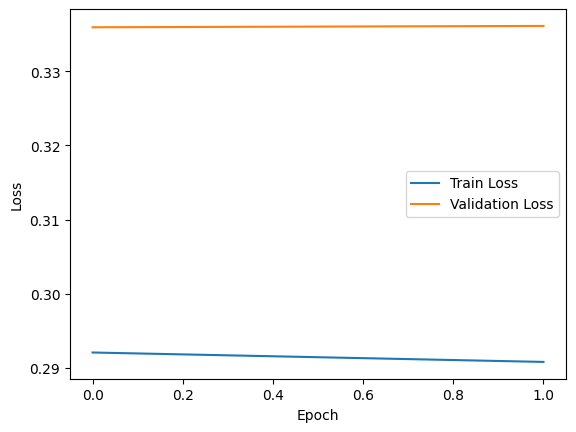

In [ ]:
plt.plot(base_train_loss, label='Train Loss')
plt.plot(base_val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
base_model_name = f'{common_file_name}.pt'
# define the path to save the model
base_model_path = os.path.join(base_model_dir, base_model_name)

In [ ]:
# save the model to the specified path
if not os.path.exists(os.path.dirname(base_model_path)):
    os.makedirs(os.path.dirname(base_model_path))
torch.save(base_model.state_dict(), base_model_path)
print(f'The base trained model: {base_model_name} has been successfully saved: "{base_model_path}".\n')

The base trained model: TL_BM_TCN_1.0_MSE_BO_4.0_7.0_1.0_23062023.pt has been successfully saved: "/content/gdrive/My Drive/TL_A/DeepKale/experiments_0.2/result/base_result/model/TL_BM_TCN_1.0_MSE_BO_4.0_7.0_1.0_23062023.pt".



In [ ]:
if os.path.exists(base_model_path):
    base_model.load_state_dict(torch.load(base_model_path))
    base_test_loss, base_y_pred = test(device = device, model = base_model, test_loader = base_test_loader, loss_fn = base_loss_fn)
else:
    print(f"File not found at path: {base_model_path}\n")

Test Loss: 0.3361



In [ ]:
base_result_df, base_result_df_daily = process_data(
    y_test=base_y_test,
    y_pred=base_y_pred,
    scaling_type = 'robust',
    scaling_params=base_robust_scaling_params,
    connection_time_list=base_connection_time_list,
    train_df=base_train_df,
    val_df=base_val_df,
    scaled_df=base_scaled_df,
    n_past=N_PAST,
    n_future=N_FUTURE
)

In [ ]:
# Save base_result_df as pickle
base_result_df_file_name = f'{common_file_name}_base_result_df.pkl'
base_result_df_file_path = os.path.join(base_test_result_dir, base_result_df_file_name)
base_result_df.to_pickle(base_result_df_file_path)
print(f"Base result DataFrame {base_result_df_file_name} has been successfully saved: {base_result_df_file_path}.\n")

# Save base_result_df_daily as pickle
base_result_df_daily_file_name = f'{common_file_name}_base_result_df_daily.pkl'
base_result_df_daily_file_path = os.path.join(base_test_result_dir, base_result_df_daily_file_name)
base_result_df_daily.to_pickle(base_result_df_daily_file_path)
print(f"Base result daily DataFrame {base_result_df_daily_file_name} has been successfully saved: {base_result_df_daily_file_path}.\n")

Base result DataFrame TL_BM_TCN_1.0_MSE_BO_4.0_7.0_1.0_23062023_base_result_df.pkl has been successfully saved: /content/gdrive/My Drive/TL_A/DeepKale/experiments_0.2/result/base_result/test_result/TL_BM_TCN_1.0_MSE_BO_4.0_7.0_1.0_23062023_base_result_df.pkl.

Base result daily DataFrame TL_BM_TCN_1.0_MSE_BO_4.0_7.0_1.0_23062023_base_result_df_daily.pkl has been successfully saved: /content/gdrive/My Drive/TL_A/DeepKale/experiments_0.2/result/base_result/test_result/TL_BM_TCN_1.0_MSE_BO_4.0_7.0_1.0_23062023_base_result_df_daily.pkl.



In [ ]:
base_mae, base_r2, base_mse, base_rms = performance_metrics(result_df = base_result_df_daily)

In [ ]:
print(f"Base MAE: {base_mae}")
print(f"Base R2 score: {base_r2}")
print(f"Base MSE: {base_mse}")
print(f"Base RMS: {base_rms}\n")

Base MAE: 1.9018462158007992
Base R2 score: -0.9819610432024213
Base MSE: 5.142898111086856
Base RMS: 2.2677958706829977



In [ ]:
# save the performance metrics in a separate pickle file
base_performance_metrics_filename = f'{common_file_name}_performance_metrics.pkl'
base_performance_metrics_path = os.path.join(base_permormance_metrics_dir, base_performance_metrics_filename)
with open(base_performance_metrics_path, 'wb') as f:
    '''Saving the performance matrix'''
    pkl.dump({'base test loss': base_test_loss, 'base mae': base_mae, 'base r2': base_r2, 'base mse': base_mse, 'base rms': base_rms}, f)

print(f"Performance metrics for base model: {base_performance_metrics_filename} has been successfully saved to {base_performance_metrics_path}\n")

Performance metrics for base model: TL_BM_TCN_1.0_MSE_BO_4.0_7.0_1.0_23062023_performance_metrics.pkl has been successfully saved to /content/gdrive/My Drive/TL_A/DeepKale/experiments_0.2/result/base_result/performance_metrics/TL_BM_TCN_1.0_MSE_BO_4.0_7.0_1.0_23062023_performance_metrics.pkl



In [ ]:
create_line_plot(base_result_df_daily, title = 'Actual vs Predicted kWh Delivered Avg Daily-Base TCN Model')